# Full Model Fine-Tuning and partial fine-tuning
This example notebook presents how fine-tuning can be applied to the a pytorch model using built-in Darts features.

The following fine-tuning methods will be shown:
1) **Full fine-tuning**: All model weights are retrained. This is natively supported by setting `enable_finetuning=True`.
2) **Partial fine-tuning**: Specific layers are frozen via name patterns. This is natively supported using the `enable_finetuning` parameter with a dictionary configuration.

To be useful, a fine-tuned model should be easily saved and loaded. We will also demonstrate how to persist the model weights.

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
# fix python path if working locally
from utils import fix_pythonpath_if_working_locally

fix_pythonpath_if_working_locally()
%matplotlib inline

In [3]:
import warnings

import numpy as np

from darts.datasets import AirPassengersDataset
from darts.models import Chronos2Model, TiDEModel
from darts.utils.likelihood_models.torch import QuantileRegression

warnings.filterwarnings("ignore")
import logging

logging.disable(logging.CRITICAL)

## Data Preparation
Here we just load an example dataset with 144 samples as a fast demo. The data is split between train and validation, with the 2 last years (24 samples) for validation

In [4]:
# convert to float32 as Chronos-2 works with float32 input
data = AirPassengersDataset().load().astype(np.float32)
train_passengers, val_passengers = data.split_before(
    len(data) - 2 * 12
)  # last 2 years for validation

## Regular PyTorch Model

Training: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

<Axes: title={'center': 'Trained TiDE model'}, xlabel='Month'>

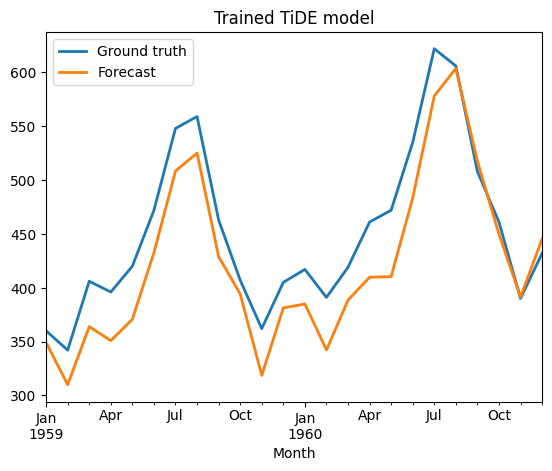

In [15]:
model = TiDEModel(
    input_chunk_length=24,
    output_chunk_length=12,
    use_reversible_instance_norm=True,
    likelihood=QuantileRegression([0.1, 0.5, 0.9]),
    random_state=42,
    n_epochs=100,
    model_name="my_model",
    save_checkpoints=True,
    force_reset=True,
)

model.fit(train_passengers, verbose=True)
prediction = model.predict(
    n=len(val_passengers), series=train_passengers, random_state=42
)
val_passengers.plot(label="Ground truth")
prediction.plot(label="Forecast", title="Trained TiDE model")

Predicting: |          | 0/? [00:00<?, ?it/s]

<Axes: title={'center': 'Trained TiDE model'}, xlabel='Month'>

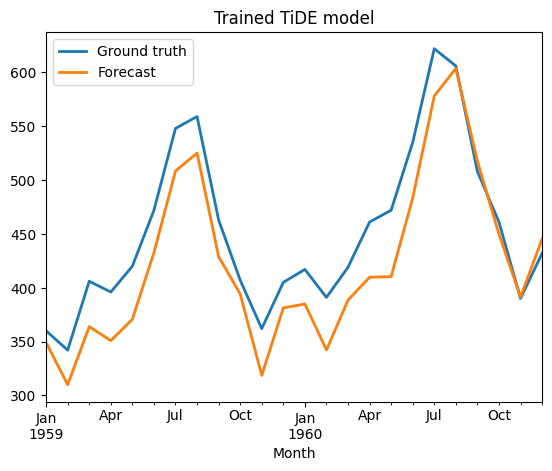

In [16]:
loaded_model = TiDEModel.load_from_checkpoint(
    model_name="my_model", best=False, map_location="cpu"
)

prediction = model.predict(
    n=len(val_passengers),
    series=train_passengers,
    random_state=42,
)
val_passengers.plot(label="Ground truth")
prediction.plot(label="Forecast", title="Trained TiDE model")

# Model prediction out-of-the-box
Let's see how the model behaves on the validation data without any fine-tuning. For that we:
- Create the model
- Call fit to load the model internally (no training is done)
- Predict on the validation set

Predicting: |          | 0/? [00:00<?, ?it/s]

<Axes: title={'center': 'Base model (not finetuned yet)'}, xlabel='Month'>

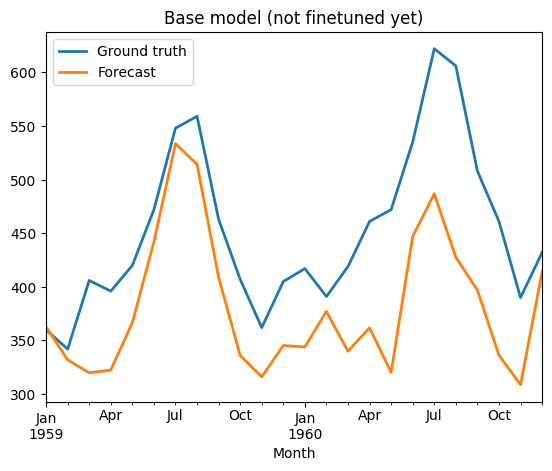

In [ ]:
model = Chronos2Model(
    input_chunk_length=24,
    output_chunk_length=12,
    likelihood=QuantileRegression([0.1, 0.5, 0.9]),
    enable_finetuning=False,
    random_state=42,
)

model.fit(train_passengers, verbose=True)

prediction = model.predict(
    n=len(val_passengers),
    series=train_passengers,
)
val_passengers.plot(label="Ground truth")
prediction.plot(label="Forecast", title="Base model (not finetuned yet)")

# 1. Full fine-tuning

In this method, all the model weights are retrained. This is simply enabled by passing `enable_finetuning=True` to the model constructor. 

When fine-tuning is enabled, Darts will treat the foundation model like a standard trainable model during `fit()`. Saving and loading follows the standard Darts API via the `save()` and `load()` methods.


In [6]:
full_finetuned_model = Chronos2Model(
    input_chunk_length=24,
    output_chunk_length=12,
    # likelihood=QuantileRegression([0.1, 0.5, 0.9]),
    enable_finetuning=True,
    n_epochs=100,
    pl_trainer_kwargs={"accelerator": "gpu"},
    random_state=42,
)
full_finetuned_model.fit(train_passengers, verbose=True)
full_finetuned_model.save("full_finetuned.pt")

# Load
full_finetuned_loaded_model = Chronos2Model.load("full_finetuned.pt")

Training: |          | 0/? [00:00<?, ?it/s]

We can compare the prediction with the ground truth, as well as checking that the loaded model behaves similarly to the fine-tuned model.

Predicting: |          | 0/? [00:00<?, ?it/s]

<Axes: title={'center': 'Full finetuning'}, xlabel='Month'>

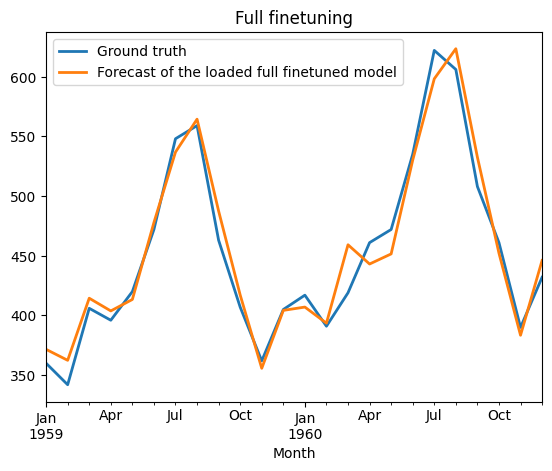

In [7]:
pred_full_finetuned_loaded = full_finetuned_loaded_model.predict(
    n=len(val_passengers),
    series=train_passengers,
)
val_passengers.plot(label="Ground truth")
pred_full_finetuned_loaded.plot(
    label="Forecast of the loaded full finetuned model",
    title="Full finetuning",
)

We can also verify numericaly that the prediction of the trained model is identical to the prediction of the loaded model

# 2. Partial fine-tuning with layer freezing

Partial fine-tuning allows you to update only a subset of the model's parameters, which is useful for preserving general knowledge while adapting to specific patterns. 

Darts foundation models natively support this via the `enable_finetuning` parameter. You can pass a dictionary with:
- `{'freeze': ['pattern1', 'pattern2']}`: To freeze specific layers (keeping others trainable).
- `{'unfreeze': ['pattern1', 'pattern2']}`: To freeze everything *except* the matching layers.

In this example, we will unfreeze only the output head of the model.

In [8]:
partial_finetuned_model = Chronos2Model(
    input_chunk_length=24,
    output_chunk_length=12,
    # likelihood=QuantileRegression([0.1, 0.5, 0.9]),
    # enable_finetuning={"unfreeze": ["output_patch_embedding"]},
    enable_finetuning={"freeze": ["*encoder*"]},
    n_epochs=100,
    pl_trainer_kwargs={"accelerator": "gpu"},
    random_state=42,
)
partial_finetuned_model.fit(train_passengers, verbose=True)
partial_finetuned_model.save("partial_finetuned.pt")

# Load - no callback needed, structure unchanged
partial_finetuned_loaded_model = Chronos2Model.load("partial_finetuned.pt")

Training: |          | 0/? [00:00<?, ?it/s]

Predicting: |          | 0/? [00:00<?, ?it/s]

<Axes: title={'center': 'Partial finetuning'}, xlabel='Month'>

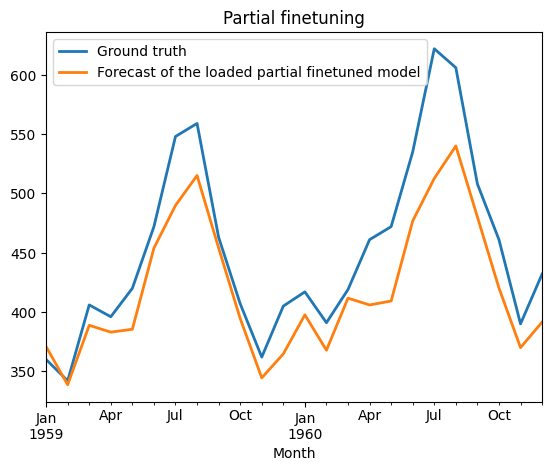

In [9]:
pred_partial_finetuned_loaded = partial_finetuned_loaded_model.predict(
    n=len(val_passengers),
    series=train_passengers,
    random_state=42,
)
val_passengers.plot(label="Ground truth")
pred_partial_finetuned_loaded.plot(
    label="Forecast of the loaded partial finetuned model",
    title="Partial finetuning",
)

Again, we verify that the prediction of the fine-tuned model is the same as the loaded model to make sure that saving/load works correctly

# 3. Performance Evaluation

Finally, let's compare the performance of the three models (Base, Full Fine-tuning, and Partial Fine-tuning) on the validation set using standard metrics like **MAPE** (Mean Absolute Percentage Error) and **MAE** (Mean Absolute Error).

In [10]:
import pandas as pd

from darts.metrics import mae, mape

results = []
all_predictions = {
    "Base Model": prediction,
    "Full Fine-tuning": pred_full_finetuned_loaded,
    "Partial Fine-tuning": pred_partial_finetuned_loaded,
}

for name, pred in all_predictions.items():
    results.append({
        "Model": name,
        "MAPE (%)": mape(val_passengers, pred),
        "MAE": mae(val_passengers, pred),
    })

df_results = pd.DataFrame(results)
df_results

,Model,MAPE (%),MAE
0,Base Model,15.206929,70.817078
1,Full Fine-tuning,2.871620,12.922942
2,Partial Fine-tuning,6.979350,33.685387


### Observations

While the results on this small "toy" dataset (Air Passengers) may vary depending on the random seed and hyperparameters, they demonstrate the flexibility of the fine-tuning API.

In real-world scenarios with larger datasets:
- **Full Fine-tuning** offers the most flexibility but is computationally expensive and prone to "catastrophic forgetting".
- **Partial Fine-tuning** provides a good middle ground by updating only the most relevant layers (like the output head).

### Summary
In this notebook, we have seen:
1. How to enable **native full fine-tuning** in Darts foundation models.
2. How to use **layer freezing patterns** to perform partial fine-tuning without manual weight manipulation.